[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__XGBoost__](./05.1_Divvy_modeling_xgboost.ipynb) | [__RNN__](./05.2_Divvy_modeling_rnn.ipynb) | [__ARIMAX__](./05.3_Divvy_modeling_arimax.ipynb) | [__Ensemble__](./05.4_Divvy_modeling_ensemble.ipynb) | [__Home__](../README.md)

# Divvy: Bike Sharing Forecast
## Forecasting

__Dataset:__ [Divvy Data](https://divvybikes.com/system-data) \
__Author:__ [Dmitry Luchkin](https://www.linkedin.com/in/dmitry-luchkin/) \
__Date:__ May 2025

> **Attention**
>
> The data utilized in this project were sourced from the official public data provided by Divvy. All analysis, results, and insights presented in this notebook were conducted and formulated by Dmitry Luchkin. I declare that I am not affiliated with Divvy, Lyft, the City of Chicago, or any associated organizations. The views and interpretations expressed herein are solely my own and do not represent the positions or policies of these entities.

### Notebooks <a class="anchor" name='notebooks'></a>

+ [Initial Data Exploration](./01_Divvy_data_exploration.ipynb)
+ [Data Cleaning](./02_Divvy_data_cleaning.ipynb)
+ [Exploratory Data Analysis](./03_Divvy_exploratory_data_analysis.ipynb)
+ [Feature Engineering](./04_Divvy_feature_engineering.ipynb)
+ Modeling & Validation:
  - [XGBoost: Modeling & Validation](./05.1_Divvy_modeling_xgboost.ipynb)
  - [RNN: Modeling & Validation](./05.2_Divvy_modeling_rnn.ipynb)
  - [ARIMAX: Modeling & Validation](./05.3_Divvy_modeling_arimax.ipynb)
  - [Ensemble: Modeling & Validation](./05.4_Divvy_modeling_ensemble.ipynb)
+ __[Forecasting](./06_Divvy_forecasting.ipynb)__

### Import Libraries <a name='import-libraries'></a>

In [1]:
import os 
import sys
import pickle
import warnings

import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series

from pmdarima import auto_arima

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
sys.path.append('../02_scripts/')

# import project code
from utils.plotting import notebook_setup
from utils.plotting.notebook_setup import TRAIN_COLOR, TEST_COLOR, FORECAST_COLOR
from utils.plotting.viz import plot_trips, distplot, check_residuals, plot_window_size
from utils.model.tools import load_dump
from utils.model.seed import set_seed

2025-05-19 17:49:56.797092: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
set_seed(42)

Seed 42 has been set.


### Loading Data <a name='loading-data'></a>

In [4]:
train_filename = "../00_data/02_processed/divvy_train.pkl"
test_filename = "../00_data/02_processed/divvy_test.pkl"
train = None
test = None
# load training set
with open(train_filename, 'rb') as f:
        train = pickle.load(f)

# load test set
with open(test_filename, 'rb') as f:
        test = pickle.load(f)

In [5]:
# xgboost dump
xgboost_models_dump = load_dump("../03_models/01_xgboost/xgboost_models_dump.pkl")
# rnn dump
rnn_models_dump = load_dump("../03_models/02_rnn/rnn_models_dump.pkl")
# harimax dump
harimax_models_dump = load_dump("../03_models/03_arimax/arimax_models_dump.pkl")
# ensemble
ensemble_dump = load_dump("../03_models/04_ensemble/ensemble_models_dump.pkl")

### XGBoost: future

In [25]:
import os
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from utils.model.tools import add_lags
import xgboost as xgb
from xgboost import XGBRegressor
import holidays


def load(file_path):
    """
    Load a single CSV file into a DataFrame.

    Parameters:
        file_path : str
            Absolute or relative path to the CSV file.

    Returns:
        pandas.DataFrame
            Data contained in *file_path*.
    """
    #print(f'{x} loading...')
    return pd.read_csv(x)

    
def load_weather_features():
    """
    Read and clean future weather forecasts stored as daily CSV files.

    Returns:
        pandas.DataFrame
            Daily weather features indexed by date.
    """
    external_dir = "../00_data/03_external/weather/future/"
    files = [external_dir + file for file in os.listdir(external_dir) if file.endswith('.csv')]
    future_weather = pd.concat(map(load, files), ignore_index=True)
    future_weather['datetime'] = pd.to_datetime(future_weather['datetime'], format='mixed')
    future_weather.drop(columns=['name', 'tempmax', 'tempmin', 'feelslikemax',
                      'feelslikemin', 'dew', 'preciptype', 'solarradiation', 
                      'solarenergy', 'uvindex', 'severerisk', 'sunrise',
                      'sunset', 'moonphase', 'description', 'icon', 'stations'], inplace=True)
    df_split = future_weather["conditions"].str.get_dummies(sep=", ")
    future_weather = pd.concat([future_weather, df_split], axis=1)
    future_weather.drop(["conditions"], axis=1, inplace=True)
    future_weather.set_index("datetime", inplace=True)
    future_weather = future_weather.asfreq("D")

    return future_weather


# ---------------------------------------------------------------------
# Feature-engineering helpers
# ---------------------------------------------------------------------
def make_timestamp_features(start, end):
    """
    Generate standard calendar features (year, quarter, month, day, season, weekday).

    Parameters:
        start, end : str or pandas.Timestamp
            Inclusive range of dates for which the features will be built.

    Returns:
        pandas.DataFrame
            Index = daily DatetimeIndex, columns = calendar attributes.
    """
    data_range = pd.date_range(start=start, end=end, freq='D')
    df = pd.DataFrame(index=data_range)
    df['year'] = df.index.year
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['season'] = df['month'] % 12 // 3 + 1 
    df['weekday'] = df.index.dayofweek
    
    return df

    
def make_holiday_feature(start, end):
    """
    Flag U.S.-Illinois public holidays in the given date range.

    Parameters:
        start, end : str or pandas.Timestamp
            Inclusive range of dates for which the feature will be built.

    Returns:
        pandas.DataFrame
            Single-column frame called is_holiday (0/1 integer flag).
    """
    us_il_holidays = holidays.country_holidays('US', subdiv='IL')
    data_range = pd.date_range(start=start, end=end, freq='D')
    df = pd.DataFrame(index=data_range)
    df["is_holiday"] = df.index.map(lambda x: x in us_il_holidays)
    df["is_holiday"] = df["is_holiday"].astype(np.int32)
    
    return df


def make_time_index_feature(start, end):
    """
    Create a simple monotonic integer time_index (0, 1, 2, …).
    
    Parameters:
        start, end : str or pandas.Timestamp
            Inclusive range of dates for which the feature will be built.

    Returns:
        pandas.DataFrame
            Single-column frame time_index aligned with the date index.
    """
    data_range = pd.date_range(start=start, end=end, freq='D')
    df = pd.DataFrame(index=data_range)
    df["time_index"] = np.arange(len(data_range))
    
    return df
    
    
def iterative_forecast_xgb(dump: dict, 
                           historic_data: pd.DataFrame, 
                           target_name: str, 
                           horizon: int) -> list[float]:
    """
    Retrain an XGBoost model stored in dump and produce a multi-step
    forecast using an auto-regressive strategy (predictions become lags).

    The same feature pipeline used during the original training run is
    reconstructed on both historic and future horizons.

    Parameters:
        dump : dict
            Pre-saved model metadata (predictor groups, params, lags, etc.).
        historic_data : pandas.DataFrame
            DataFrame with the target series and any weather columns needed.
        target_name : str
            Column in @historic_data to be forecast.
        horizon : int
            Number of future days to predict.

    Returns:
        list[float]
            Point forecasts for @horizon consecutive days, in chronological
            order.
    """
    # -----------------------------------------------------------------
    # Unpack saved model configuration
    # -----------------------------------------------------------------
    # list of group of predictors
    predictors = dump["xgboost"][target_name]["predictors"]
    # xgboost params were searched during the training
    xgb_params = dump["xgboost"][target_name]["model"]["params"]
    # transformation was appllied to the original series
    transformation = dump["xgboost"][target_name]["model"]["transformation"]
    bc_lambda = dump["xgboost"][target_name]["model"].get("lambda", None)
    # informative lags were added during the training
    informative_lags = dump["xgboost"][target_name]["model"]["lags"]

    print("\n*** XGBoost: Iterative Forecasting ***\n")
    print(f"Target Variable: {target_name}")
    print(f"Predictors: {predictors}")
    print(f"XGBoost Params: {xgb_params}")
    print(f"Transformation: {transformation} (lambda={bc_lambda})")
    print(f"Informative Lags: {informative_lags}")
    
    # -----------------------------------------------------------------
    # Assemble training frame
    # -----------------------------------------------------------------
    elements = {"time_index": {"features": ["time_index"], "add_lags": False}, 
                    "lags": {"features": [], "add_lags": True}, 
                    "timestamps": {"features": ["year", "quarter", "month", "day", "season", "weekday"], "add_lags": False}, 
                    "holidays": {"features": ["is_holiday"], "add_lags": False}, 
                    "weather": {"features": ["temp", "feelslike",
                                               "humidity", "precip", "precipprob", "precipcover", "snow", "snowdepth",
                                               "windgust", "windspeed", "winddir", "sealevelpressure", "cloudcover",
                                               "visibility", "Clear", "Freezing Drizzle/Freezing Rain", "Ice",
                                               "Overcast", "Partially cloudy", "Rain", "Snow"], "add_lags": False},
                   }
    
    features = []
    addlags = False
    for item in predictors:
        features.extend(elements[item]["features"])
        addlags |= elements[item]["add_lags"]

    train_xgb = pd.DataFrame(historic_data[target_name])

    # -----------------------------------------------------------------
    # Apply target transformation
    # -----------------------------------------------------------------
    if transformation == "log":
        train_xgb[target_name] = np.log(train_xgb[target_name])
    elif transformation == "log1p":
        train_xgb[target_name] = np.log1p(train_xgb[target_name])
    elif transformation == "boxcox":
        train_xgb[target_name] = boxcox(train_xgb[target_name], lmbda=bc_lambda)

    # -----------------------------------------------------------------
    # Feature engineering on the historic range
    # -----------------------------------------------------------------
    
    # add time_index
    if "time_index" in predictors:
        time_index_df = make_time_index_feature(start=historic_data.index.min(),
                                            end=historic_data.index.max())
        train_xgb = pd.concat([train_xgb, time_index_df], axis=1)
        
    # add lags
    if addlags:
        train_xgb = add_lags(train_xgb, target_name, lags=informative_lags)

    # add timestamps
    if "timestamps" in predictors:
        timestamps_df = make_timestamp_features(start=historic_data.index.min(),
                                            end=historic_data.index.max())
        train_xgb = pd.concat([train_xgb, timestamps_df], axis=1)

    # add holidays
    if "holidays" in predictors:
        holidays_df = make_holiday_feature(start=historic_data.index.min(),
                                            end=historic_data.index.max())
        train_xgb = pd.concat([train_xgb, holidays_df], axis=1)

    # add weather
    if "weather" in predictors:
        weather_df = historic_data[elements["weather"]["features"]]
        train_xgb = pd.concat([train_xgb, weather_df], axis=1)

    X = train_xgb.drop(columns=[target_name])
    y = train_xgb[target_name]

    # -----------------------------------------------------------------
    # Retrain the model
    # -----------------------------------------------------------------
    print("Retraining the model...")
    regressor = XGBRegressor(**xgb_params, objective='reg:squarederror', tree_method='hist')
    regressor.fit(X, y)

    print("Forecasting...")

    # -----------------------------------------------------------------
    # Create future feature grids
    # -----------------------------------------------------------------
    weather_features = load_weather_features()
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    timestamps_features = make_timestamp_features(start=forecast_start, end=forecast_end)
    holidays_features = make_holiday_feature(start=forecast_start, end=forecast_end)
    historic_nrow = len(train_xgb)
    time_index_feature = pd.DataFrame({"time_index": np.arange(historic_nrow, historic_nrow+horizon)}, 
                                      index=pd.date_range(forecast_start, forecast_end, freq="D"))
    
    # -----------------------------------------------------------------
    # Auto-regressive loop (each prediction fed back as a new lag)
    # -----------------------------------------------------------------
    lags_forecast = pd.DataFrame(y)
    y_preds = [] # to keep predictions
    for h in np.arange(1, horizon + 1):
        time_index_forecast = time_index_feature.iloc[[h-1]] if "time_index" in predictors else None
        timestamps_forecast = timestamps_features.iloc[[h-1]] if "timestamps" in predictors else None
        holidays_forecast = holidays_features.iloc[[h-1]] if "holidays" in predictors else None
        weather_forecast = weather_features.iloc[[h-1]] if "weather" in predictors else None
        
        if addlags:
            next_index = lags_forecast.index.max() + pd.Timedelta(days=1)
            next_row = pd.DataFrame({target_name: [np.nan]}, index=[next_index])
            lags_forecast = pd.concat([lags_forecast, next_row], axis=0)
            lags_forecast = add_lags(lags_forecast, target_name, lags=informative_lags)
        else:
            lags_forecast = None
        
        test_xgb = pd.concat([time_index_forecast, 
                              lags_forecast.iloc[-1:, 1:],
                              timestamps_forecast, 
                              holidays_forecast, 
                              weather_forecast], axis=1, join='inner')
        
        y_pred = regressor.predict(test_xgb)[0]
        y_preds.append(y_pred)
        lags_forecast.iloc[-1, 0] = y_pred

    # -----------------------------------------------------------------
    # Invert transformation to original scale
    # -----------------------------------------------------------------
    if transformation == "log":
        y_preds = np.exp(y_preds)
    elif transformation == "log1p":
        y_preds = np.expm1(y_preds)
    elif transformation == "boxcox":
        y_preds = inv_boxcox(y_preds, bc_lambda)

    print("Done!")
    
    return y_preds
    

### RNN/LSTM: future

In [7]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

def make_rnn(window_size):
    """
    Construct and compile a two-branch LSTM.

    Parameters:
        window_size : int
            Number of lagged steps (timesteps) presented to the recurrent
            branch.  Each step contains one feature – the target value.

    Returns:
        tensorflow.keras.Model
            Compiled model ready for training.
    """
    # Define RNN model
    input_seq = Input(shape=(window_size, 1))         # time-dependent input (lags)
    input_static = Input(shape=(28,))                 # time-independent exogenous input

    x = LSTM(64, return_sequences=True)(input_seq)
    x = Dropout(0.15)(x)

    x = LSTM(256, return_sequences=False)(x)
    x = Dropout(0.25)(x)

    x = Concatenate()([x, input_static])    # merge sequence and static inputs
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    output = Dense(1, activation="softplus")(x)  # softplus ensures non-negative output

    model = Model(inputs=[input_seq, input_static], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
                  loss='mean_squared_error')

    return model
    

def iterative_forecast_rnn(dump, historic_data, target_name, horizon, verbose=1):
    """
    Fit an LSTM on past data and roll it forward one day at a time.

    The function mirrors the workflow used during training (hyper-
    parameters reside in @dump) so that back-testing and live serving
    stay consistent.

    Parameters:
        dump : dict
            Serialized metadata.
        historic_data : pandas.DataFrame
            Must contain the target column plus the 28 static features
            referenced inside the function.
        target_name : str
            Column in @historic_data to model and forecast.
        horizon : int
            Number of future days to predict.
        verbose : int, default 1
            Keras verbosity level for .fit() and .predict().

    Returns:
        numpy.ndarray
            Vector of length @horizon containing point forecasts on the
            original (inverse-scaled) scale.
    """
    # ------------------------------------------------------------------
    # Unpack model spec
    # ------------------------------------------------------------------
    window_size = dump["rnn"][target_name]["window_size"] # timesteps

    print("\n*** RNN/LSTM: Iterative Forecasting ***\n")
    print(f"Target Variable: {target_name}")
    print(f"Window Size: {window_size}")

    # -----------------------------------------------------------------
    # Feature selection & scaling
    # -----------------------------------------------------------------
    # Define the feature set: target + exogenous variables
    features = [target_name, 'is_holiday', 'year',
       'quarter', 'month', 'day', 'season', 'weekday', 'temp', 'feelslike',
       'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth',
       'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover',
       'visibility', 'Clear', 'Freezing Drizzle/Freezing Rain', 'Ice',
       'Overcast', 'Partially cloudy', 'Rain', 'Snow']

    # Extract training data and scale to [0, 1]
    df_train = historic_data[features]
    
    y_scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaler = MinMaxScaler(feature_range=(0, 1))

    y_scaled = y_scaler.fit_transform(df_train[[target_name]].values)
    X_scaled = X_scaler.fit_transform(df_train.drop(columns=[target_name]).values)
    
    df_train_scaled = np.hstack([y_scaled, X_scaled])
    
    # -----------------------------------------------------------------
    # Build lagged tensors for the recurrent branch
    # -----------------------------------------------------------------
    X_train = []
    y_train = []
    for i in range(window_size, len(df_train)):
        X_train.append(y_scaled[i - window_size: i, 0])  # lagged y values
        y_train.append(y_scaled[i, 0])                   # next y value

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))  # shape: (samples, time steps, 1 feature)

    # Static features (exogenous variables) from the same period
    X_train_static = np.array(X_scaled[window_size:])

    # -----------------------------------------------------------------
    # Model training
    # -----------------------------------------------------------------
    model = make_rnn(window_size)

    # Learning rate scheduling and early stopping
    lr_scheduler = ReduceLROnPlateau(monitor="loss", factor=0.8, patience=15, min_lr=1e-6)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print("Retraining...")
    
    # Train the model with 10% of the data used as validation set (last part of training set)
    history = model.fit([X_train, X_train_static], y_train,
                        epochs=100, batch_size=64,
                        verbose=verbose, callbacks=[early_stop, lr_scheduler])

    # -----------------------------------------------------------------
    # Prepare future exogenous features
    # -----------------------------------------------------------------
    print("Forecasting...")
    
    weather_features = load_weather_features()
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    timestamps_features = make_timestamp_features(start=forecast_start, end=forecast_end)
    holidays_features = make_holiday_feature(start=forecast_start, end=forecast_end)

    X_static = pd.concat([holidays_features, 
                         timestamps_features, 
                         weather_features], axis=1, join="inner")[:horizon]

    X_static_scaled = X_scaler.transform(X_static.values)

    # -----------------------------------------------------------------
    # Recursive forecasting
    # -----------------------------------------------------------------
    y_preds = [] # to keep predictions
    inputs = y_scaled[-window_size:, 0]
    for h in range(horizon):
        X_static_row = X_static_scaled[h].reshape(1, -1)
        X_test = np.reshape(inputs, (1, window_size, 1))
        
        pred_y = model.predict([X_test, X_static_row], verbose=verbose)
        inputs = np.append(inputs[1:], pred_y[0])
        y_preds.append(pred_y[0])

    # -----------------------------------------------------------------
    # Back-transform to original scale
    # -----------------------------------------------------------------
    y_preds = np.array(y_preds).reshape(-1, 1)
    y_pred_inv = y_scaler.inverse_transform(y_preds)

    print("Done!")
    
    return y_pred_inv.ravel()

### ARIMAX: future

In [8]:
for key, item in harimax_models_dump["arimax"].items():
    if item["level"] == "bottom":
        print(f"{key}: {item['model']['forecast_type']}")

casual_regular_bike: iterative
casual_electric_bike: iterative
member_regular_bike: iterative
member_electric_bike: iterative


In [9]:
from utils.model.arimax import make_harmonic_features, safe_boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX

def iterative_forecast_harimax(dump, historic_data, target_name, horizon):
    """
    Re-estimate a harmonic-ARIMAX model on @historic_data and generate
    a day-by-day forecast, recursively feeding each new prediction back
    into the state-space object.

    Parameters:
        dump : dict
            Serialized metadata.
        historic_data : pandas.DataFrame
            Must contain @target_name plus the 28 exogenous columns listed
            inside the function.
        target_name : str
            Column to model and forecast.
        horizon : int
            Number of future daily steps to predict (≥ 1).

    Returns:
        numpy.ndarray
            Vector of length @horizon containing point forecasts on the
            original (inverse-Box-Cox) scale.
    """
    # ------------------------------------------------------------------
    # Unpack model spec
    # ------------------------------------------------------------------    
    order = dump["arimax"][target_name]["model"]["order"]
    d = dump["arimax"][target_name]["model"]["d"] # is not needed, it is in the order
    #forecast_type = dump["arimax"][target_name]["model"]["forecast_type"] # is not needed

    harmonic_periods=[7, 12, 30.44, 91.31, 182.62, 365.25]
    harmonics_per_periods=[3, 3, 3, 3, 3, 3]
    exog_features = ['is_holiday', 'year',
       'quarter', 'month', 'day', 'season', 'weekday', 'temp', 'feelslike',
       'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth',
       'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover',
       'visibility', 'Clear', 'Freezing Drizzle/Freezing Rain', 'Ice',
       'Overcast', 'Partially cloudy', 'Rain', 'Snow']
    steps_ahead = 14

    print("\n*** HARIMAX: Iterative Forecasting ***\n")
    print(f"Target Variable: {target_name}")
    print(f"ARIMA Model Order: {order}")
    print(f"Difference: {d}")

    # ------------------------------------------------------------------
    # Box-Cox transform & harmonic regressors on training window
    # ------------------------------------------------------------------
    train_transformed, train_lambda, shift = safe_boxcox(historic_data[target_name])
    # farmonic features
    t = np.arange(len(historic_data))
    train_harmonics = make_harmonic_features(t, 
                                             periods=harmonic_periods, 
                                             harmonics_per_periods=harmonics_per_periods)
    
    # ------------------------------------------------------------------
    # Model refit
    # ------------------------------------------------------------------
    print("Retraining...")
    train_data = train_transformed[:-steps_ahead]
    X = np.column_stack([train_harmonics[:-steps_ahead], historic_data.iloc[:-steps_ahead][exog_features].values])
            
    model = SARIMAX(train_data, 
                    exog=X, 
                    order=order)
    results = model.fit(maxiter=100, method='powell')
    
    sarima_test_preds = []

    bar_length = 50
    
    # ------------------------------------------------------------------
    # Warm-up loop (append last 14 true obs so state is current)
    # ------------------------------------------------------------------
    print("Warming up the model...")

    for i in range(len(train_transformed) - steps_ahead, len(train_transformed)):
        exog = np.hstack([train_harmonics[i], historic_data.iloc[i][exog_features].values]).reshape(1, -1)
        pred = results.forecast(steps=1, exog=exog)[0]
        results = results.append(train_transformed[[i]], exog=exog) # update the model

    # ------------------------------------------------------------------
    # Prepare future exogenous features
    # ------------------------------------------------------------------
    print("Iterative Forecasting...")

    weather_features = load_weather_features()
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    timestamps_features = make_timestamp_features(start=forecast_start, end=forecast_end)
    holidays_features = make_holiday_feature(start=forecast_start, end=forecast_end)

    X_static = pd.concat([holidays_features, 
                         timestamps_features, 
                         weather_features], axis=1, join="inner")[:horizon]

    # ------------------------------------------------------------------
    # Iterative forecast
    # ------------------------------------------------------------------
    for i in range(len(train_transformed), len(train_transformed) + horizon):
        test_harmonics = make_harmonic_features(np.arange(i, i + 1), 
                                                         periods=harmonic_periods, 
                                                         harmonics_per_periods=harmonics_per_periods)
        exog = np.hstack([test_harmonics, X_static.iloc[i-len(train_transformed)][exog_features].values.reshape(1, -1)])
        y_pred = results.forecast(steps=1, exog=exog)[0]
        sarima_test_preds.append(y_pred)
        results = results.append([y_pred], exog=exog)

    # ------------------------------------------------------------------
    # Inverse Box-Cox back to original scale
    # ------------------------------------------------------------------
    print("Boxcox Invertion...")
    harmonic_forecast = inv_boxcox(sarima_test_preds, train_lambda) - shift
    
    print("Done!")
    
    return harmonic_forecast

### Ensembling

In [10]:
# Model configurations
model_dumps = {
    "xgboost": xgboost_models_dump,
    "rnn": rnn_models_dump,
    "harimax": harimax_models_dump,
    "ensemble": ensemble_dump
}

def ensemble_future(dumps, historic_data, target_name, horizon):
    """
    Generate and combine forecasts from several models using weighted averaging.

    Parameters:
        dumps : dict
            Dictionary of model dump configs.
        historic_data : pandas.DataFrame
            Historical time series with the target variable and required features.
        target_name : str
            The name of the column to forecast.
        horizon : int
            Number of future time steps (days) to forecast.

    Returns:
        pandas.DataFrame
            Forecast DataFrame with a row per forecasted day and one column per
            model, plus a final 'ensemble' column with the weighted average.
    """
    # models we have to use for ensembling
    models = dumps["ensemble"]["ensemble"][target_name]["models"]
    weights = [dumps["ensemble"]["ensemble"][target_name]["weights"][model] for model in models] # to be sure in the right order of weights
    
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    
    print(f"Ensemble of {models} for {target_name}")
    print(f"Weights: {weights}")
    print(f"Horizon: {horizon}")
    print(f"Start: {forecast_start:%Y-%m-%d}")
    print(f"End: {forecast_end:%Y-%m-%d}")
    
    future = pd.DataFrame(columns=models,
                          index=pd.date_range(forecast_start, forecast_end, freq="D"))
    # make future forecast
    for model in models:
        y_pred = None
        
        match model:
            case "xgboost":
                y_pred = iterative_forecast_xgb(dumps[model], historic_data, target_name, horizon)
            case "rnn":
                y_pred = iterative_forecast_rnn(dumps[model], historic_data, target_name, horizon=horizon, verbose=0)
            case "harimax":
                y_pred = iterative_forecast_harimax(dumps["harimax"], historic_data, target_name, horizon=horizon)

        future.loc[:, model] = y_pred
    # ensembling the models
    future["ensemble"] = np.dot(weights, future.values.T)
    
    return future

### Future Forecasting

In [11]:
h_data = pd.concat([train, test], axis=0)
horizon_forecast = 14

def plot_forecast(df, title):
    """
    Plot model forecasts over time, including individual model outputs and their ensemble.

    Parameters
        df : pandas.DataFrame
            Forecast DataFrame with a datetime index and one or more of the following columns:
            - 'xgboost'
            - 'rnn'
            - 'harimax'
            - 'ensemble' (required)
    
        title : str
            Title to display at the top of the plot.

    Returns:
        None
            Displays the plot using matplotlib.
    """
    if "xgboost" in df.columns:
        plt.plot(df["xgboost"], label="XGBoost", alpha=0.5)
        
    if "rnn" in df.columns:
        plt.plot(df["rnn"], label="RNN/LSTM", alpha=0.5)
    
    if "harimax" in df.columns:
        plt.plot(df["harimax"], label="HARIMAX", alpha=0.5)
        
    plt.plot(df["ensemble"], label="Ensemble")
    plt.title(title)
    plt.ylabel("Number of bike trips")
    plt.xlabel("Date")
    plt.legend()
    plt.show()

In [12]:
# Casual/Regular
cr_forecast = ensemble_future(model_dumps, h_data, "casual_regular_bike", horizon_forecast)

Ensemble of ('xgboost', 'rnn', 'harimax') for casual_regular_bike
Weights: [0.37193762071944414, 0.2533919159213382, 0.37467046335921783]
Horizon: 14
Start: 2025-01-01
End: 2025-01-14

*** XGBoost: Iterative Forecasting ***

Target Variable: casual_regular_bike
Predictors: ('lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Transformation: boxcox (lambda=0.1829280195166226)
Informative Lags: [1, 3, 5, 6, 7, 13, 14]
Retraining the model...
Forecasting...
Done!

*** RNN/LSTM: Iterative Forecasting ***

Target Variable: casual_regular_bike
Window Size: 90
Retraining...
Forecasting...
Done!

*** HARIMAX: Iterative Forecasting ***

Target Variable: casual_regular_bike
ARIMA Model Order: (5, 0, 6)
Difference: None
Retraining...
Optimization terminated successfully.
         Current function value: 1.395801
         Iterations: 9
         Function evaluations: 5788
Warming up the m

In [13]:
cr_forecast

,xgboost,rnn,harimax,ensemble
2025-01-01,309.7805,268.2682,488.8861,366.3672
2025-01-02,329.3646,314.2514,371.4770,341.3133
2025-01-03,324.7206,425.2365,304.5744,342.6423
2025-01-04,382.4535,521.7211,376.8336,415.6372
2025-01-05,331.9398,319.7938,288.1424,312.4525
2025-01-06,284.1238,51.9643,159.6011,178.6415
2025-01-07,246.1931,157.1995,215.0817,211.9863
2025-01-08,276.9951,284.7961,309.7916,291.2597
2025-01-09,246.0011,388.7819,307.9369,305.3861
2025-01-10,183.0069,88.3011,133.9829,140.6414


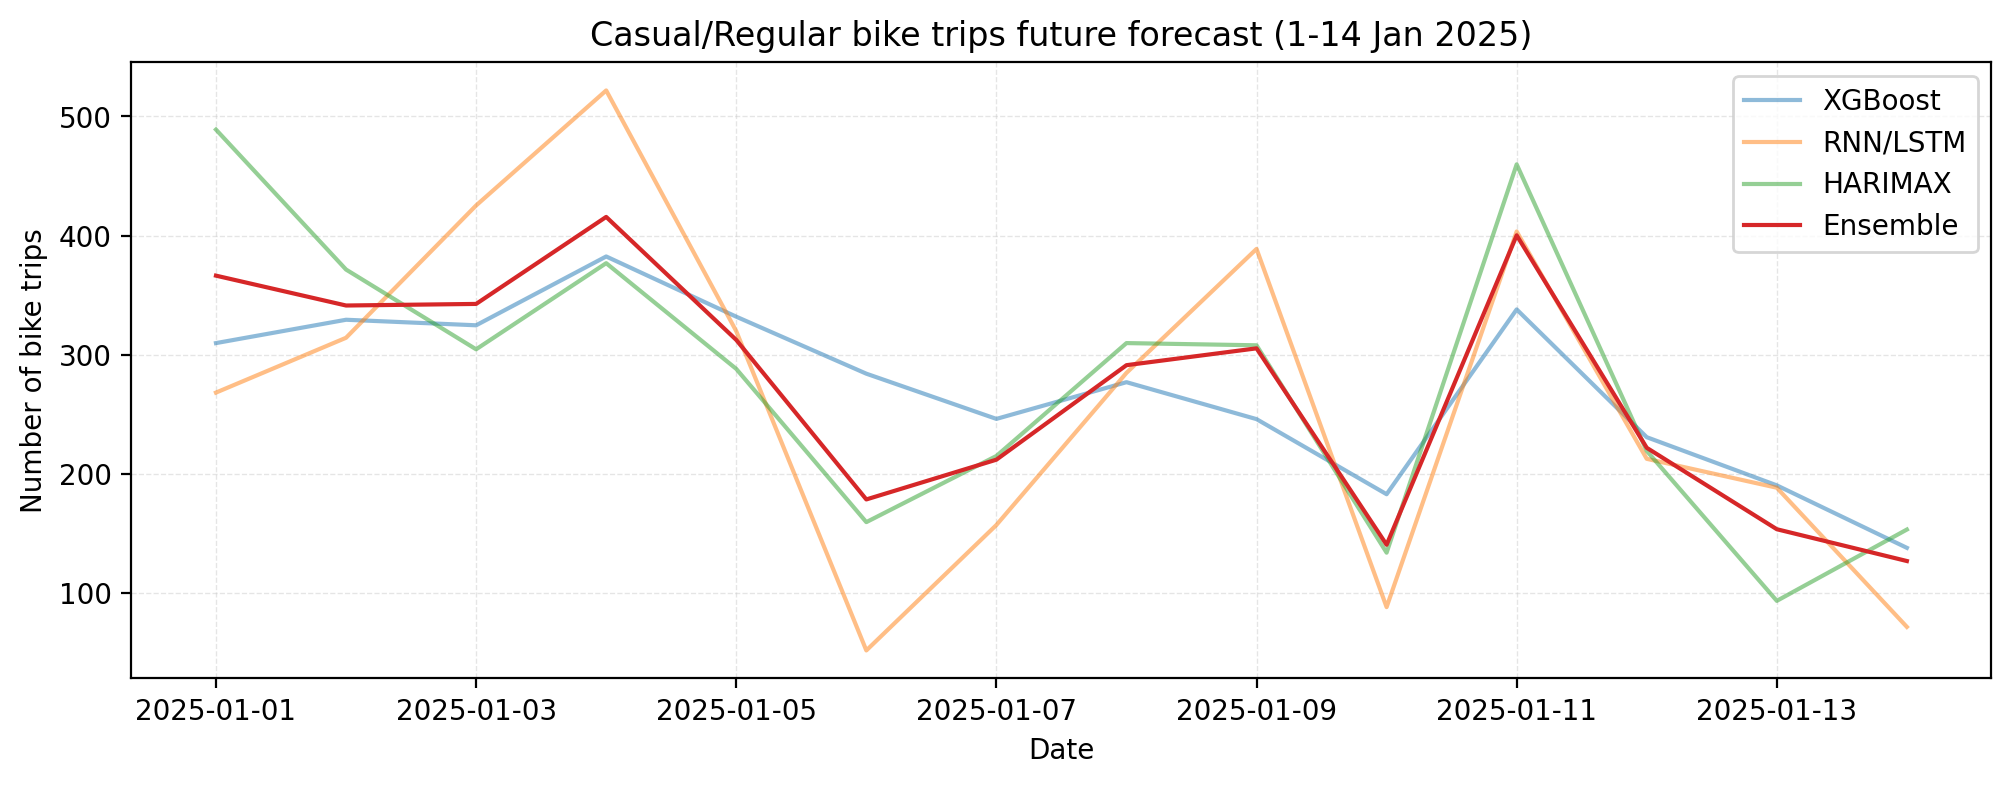

In [14]:
plot_forecast(cr_forecast, "Casual/Regular bike trips future forecast (1-14 Jan 2025)")

In [15]:
# Member/Regular
mr_forecast = ensemble_future(model_dumps, h_data, "member_regular_bike", horizon_forecast)

Ensemble of ('xgboost', 'rnn', 'harimax') for member_regular_bike
Weights: [0.3091902677240151, 0.304778971546173, 0.38603076072981196]
Horizon: 14
Start: 2025-01-01
End: 2025-01-14

*** XGBoost: Iterative Forecasting ***

Target Variable: member_regular_bike
Predictors: ('time_index', 'lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Transformation: None (lambda=None)
Informative Lags: [1, 2, 6]
Retraining the model...
Forecasting...
Done!

*** RNN/LSTM: Iterative Forecasting ***

Target Variable: member_regular_bike
Window Size: 30
Retraining...
Forecasting...
Done!

*** HARIMAX: Iterative Forecasting ***

Target Variable: member_regular_bike
ARIMA Model Order: (1, 1, 1)
Difference: 1
Retraining...
Optimization terminated successfully.
         Current function value: 5.470951
         Iterations: 4
         Function evaluations: 2167
Warming up the model...
Iterative For

In [16]:
mr_forecast

,xgboost,rnn,harimax,ensemble
2025-01-01,986.7779,"1,853.4142","2,031.0553","1,654.0336"
2025-01-02,"1,642.0474","2,269.8667","2,476.4992","2,155.5176"
2025-01-03,"1,544.5314","1,696.8394","1,768.6797","1,677.4798"
2025-01-04,"1,359.2566","1,441.8094","1,442.2777","1,416.4657"
2025-01-05,"1,269.0325","1,114.3263","1,153.9074","1,177.4395"
2025-01-06,"1,795.6652","2,074.1726","1,749.3414","1,862.6660"
2025-01-07,"2,069.6145","2,076.1995","2,020.0080","2,052.4718"
2025-01-08,"2,171.8889","2,222.6641","2,263.2605","2,222.6364"
2025-01-09,"2,086.4458","2,013.2408","2,268.5561","2,134.4347"
2025-01-10,"1,158.0986","1,278.9136","1,111.4195","1,176.9009"


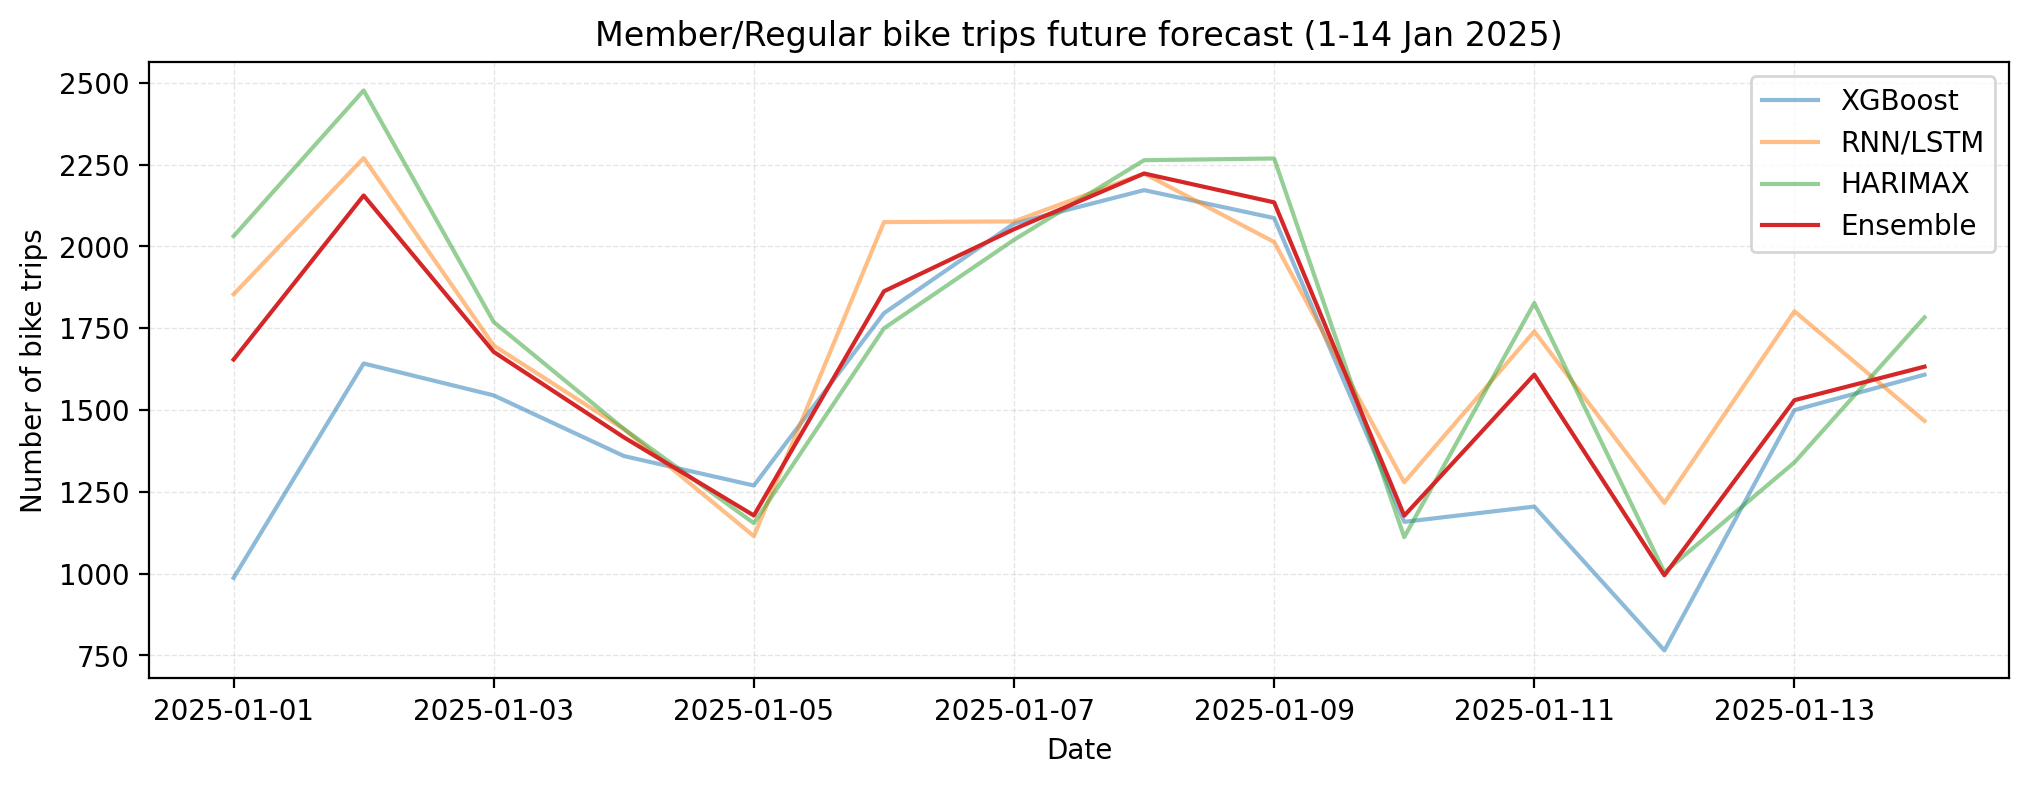

In [17]:
plot_forecast(mr_forecast, "Member/Regular bike trips future forecast (1-14 Jan 2025)")

In [18]:
# Casual/Electric
ce_forecast = ensemble_future(model_dumps, h_data, "casual_electric_bike", horizon_forecast)

Ensemble of ('xgboost', 'harimax') for casual_electric_bike
Weights: [0.45190358817772064, 0.5480964118222793]
Horizon: 14
Start: 2025-01-01
End: 2025-01-14

*** XGBoost: Iterative Forecasting ***

Target Variable: casual_electric_bike
Predictors: ('lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Transformation: log1p (lambda=None)
Informative Lags: [1, 3, 5, 6, 7]
Retraining the model...
Forecasting...
Done!

*** HARIMAX: Iterative Forecasting ***

Target Variable: casual_electric_bike
ARIMA Model Order: (6, 1, 6)
Difference: 1
Retraining...
Optimization terminated successfully.
         Current function value: 2.932678
         Iterations: 10
         Function evaluations: 6491
Warming up the model...
Iterative Forecasting...
Boxcox Invertion...
Done!


In [19]:
ce_forecast

,xgboost,harimax,ensemble
2025-01-01,399.7585,803.8637,621.2471
2025-01-02,663.1041,790.5969,732.9824
2025-01-03,537.7172,677.2070,614.1711
2025-01-04,499.8562,671.2740,593.8097
2025-01-05,456.2856,545.3018,505.0750
2025-01-06,397.2090,458.7727,430.9519
2025-01-07,345.3703,496.3040,428.0965
2025-01-08,340.4198,548.0676,454.2308
2025-01-09,417.5082,584.7493,509.1724
2025-01-10,266.7561,400.4852,340.0525


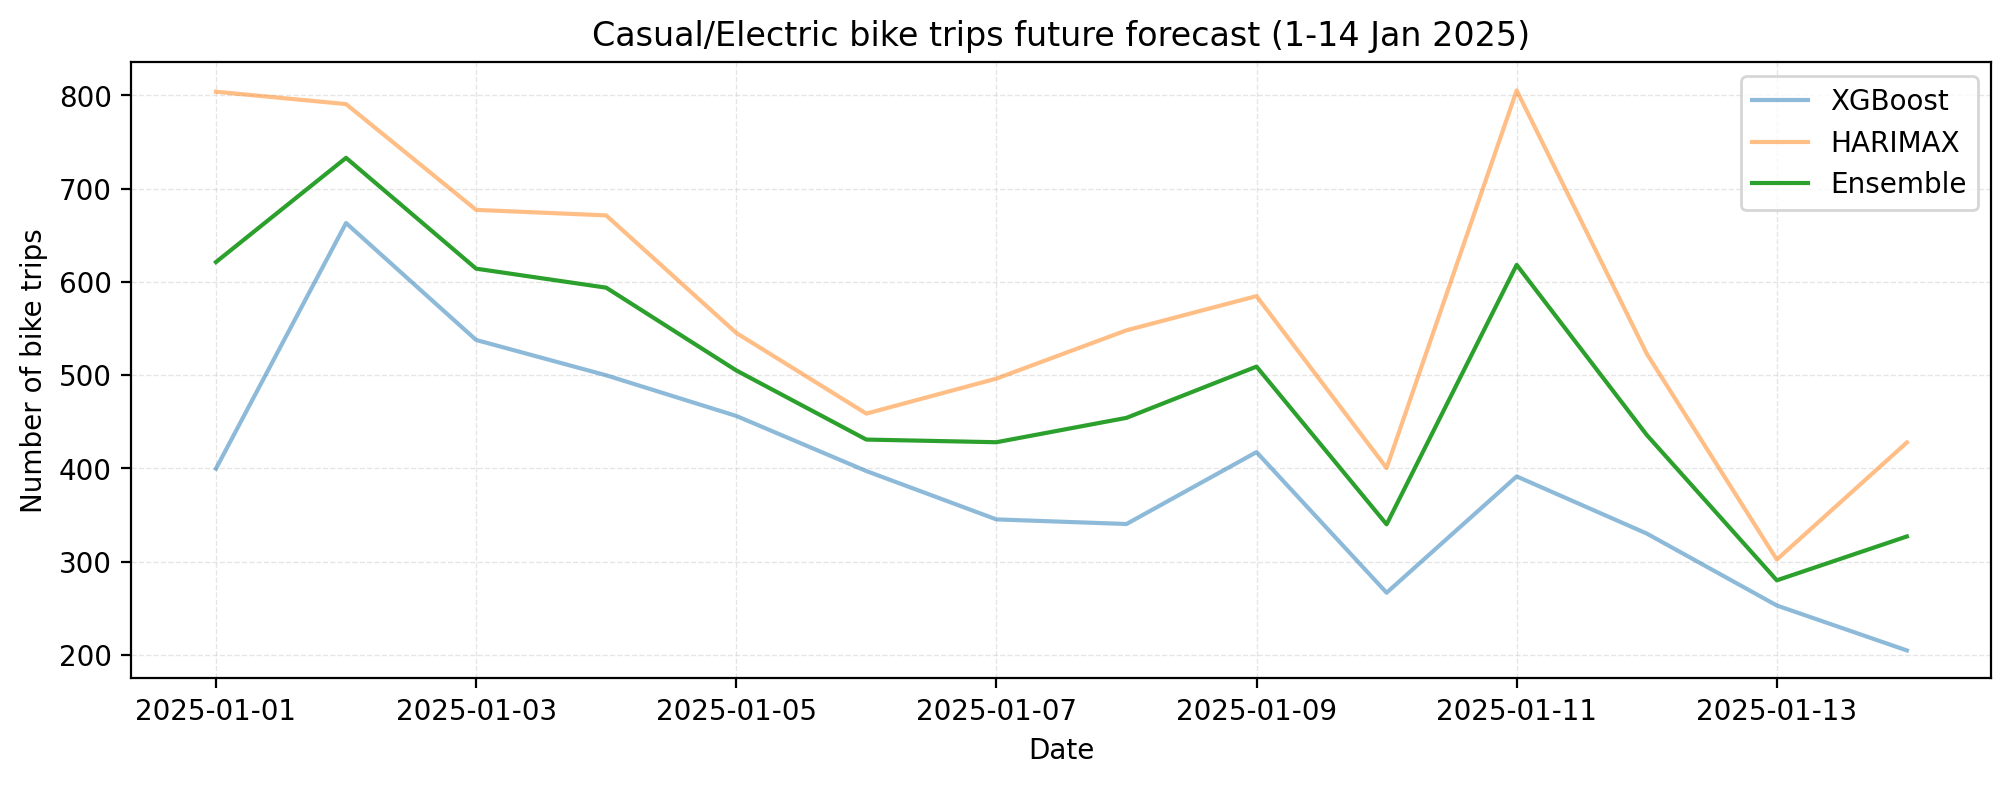

In [20]:
plot_forecast(ce_forecast, "Casual/Electric bike trips future forecast (1-14 Jan 2025)")

In [21]:
# Member/Electric
me_forecast = ensemble_future(model_dumps, h_data, "member_electric_bike", horizon_forecast)

Ensemble of ('rnn', 'harimax') for member_electric_bike
Weights: [0.39907121540546664, 0.6009287845945332]
Horizon: 14
Start: 2025-01-01
End: 2025-01-14

*** RNN/LSTM: Iterative Forecasting ***

Target Variable: member_electric_bike
Window Size: 30
Retraining...
Forecasting...
Done!

*** HARIMAX: Iterative Forecasting ***

Target Variable: member_electric_bike
ARIMA Model Order: (3, 0, 4)
Difference: None
Retraining...
Optimization terminated successfully.
         Current function value: 4.989231
         Iterations: 5
         Function evaluations: 2991
Warming up the model...
Iterative Forecasting...
Boxcox Invertion...
Done!


In [22]:
me_forecast

,rnn,harimax,ensemble
2025-01-01,"2,028.2637","2,373.8306","2,235.9248"
2025-01-02,"2,167.4028","2,993.7280","2,663.9654"
2025-01-03,"1,726.9153","2,474.8648","2,176.3797"
2025-01-04,"1,365.6232","1,933.7561","1,707.0306"
2025-01-05,"1,111.9325","1,598.4558","1,404.2984"
2025-01-06,"1,806.9844","2,035.2110","1,944.1323"
2025-01-07,"1,839.8470","2,451.3240","2,207.3012"
2025-01-08,"1,924.9042","2,805.2724","2,453.9428"
2025-01-09,"1,813.8053","2,883.0603","2,456.3514"
2025-01-10,"1,082.1290","1,956.3848","1,607.4945"


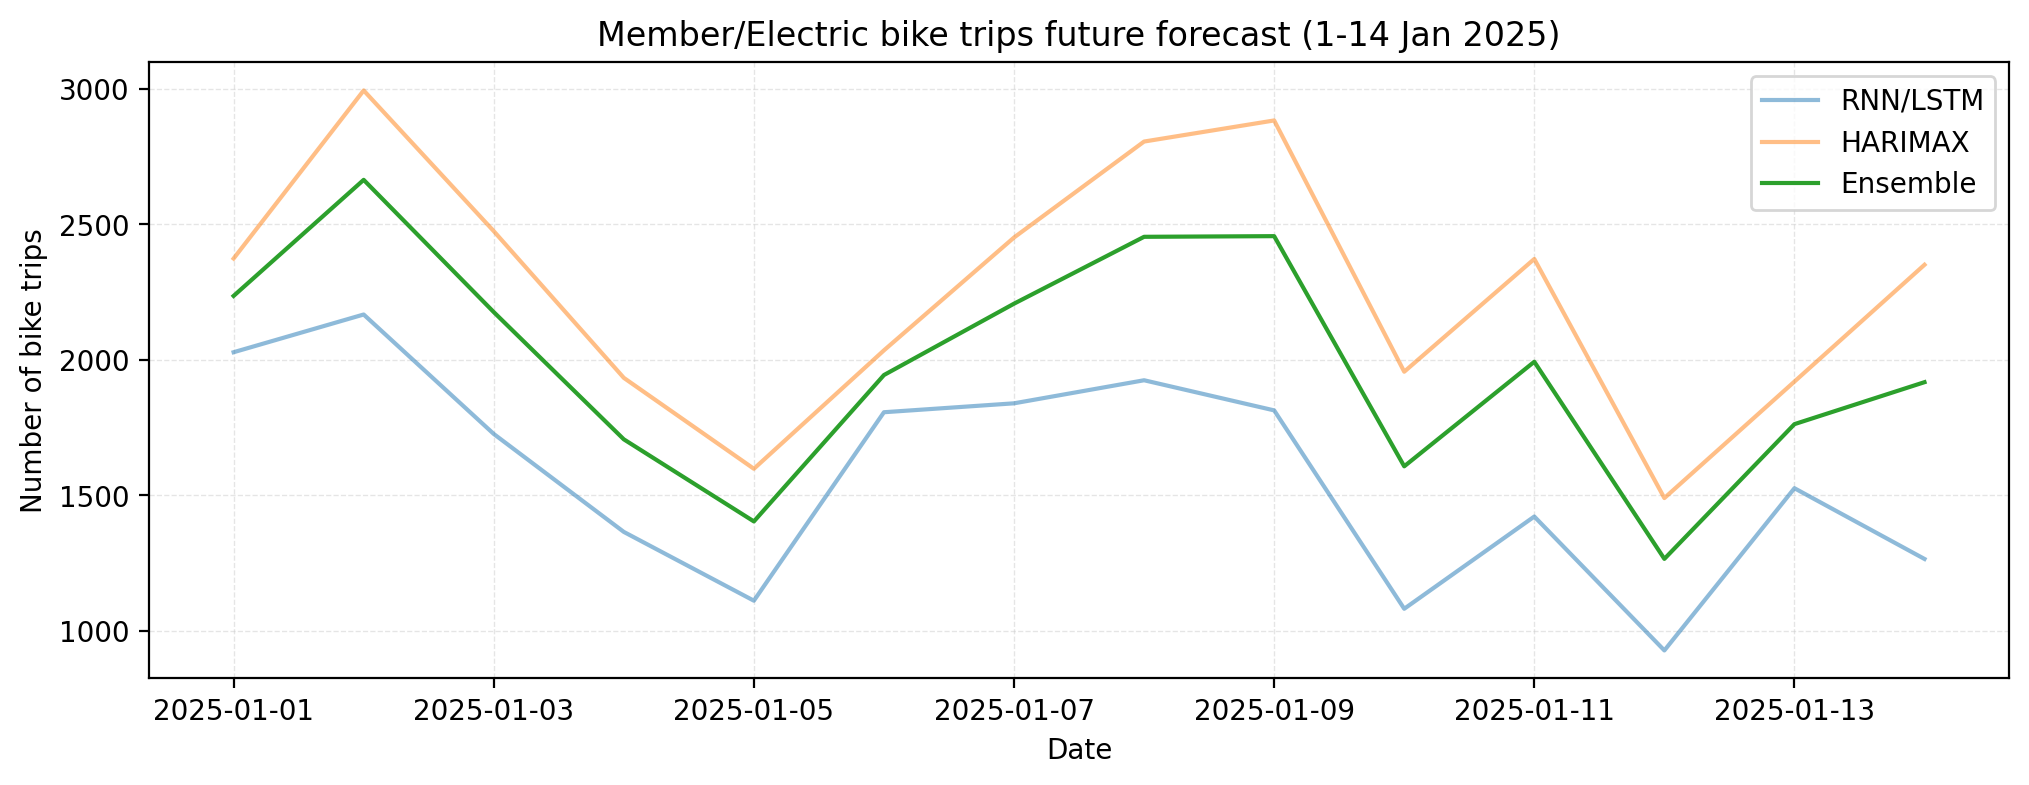

In [23]:
plot_forecast(me_forecast, "Member/Electric bike trips future forecast (1-14 Jan 2025)")


---
\
[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__XGBoost__](./05.1_Divvy_modeling_xgboost.ipynb) | [__RNN__](./05.2_Divvy_modeling_rnn.ipynb) | [__ARIMAX__](./05.3_Divvy_modeling_arimax.ipynb) | [__Ensemble__](./05.4_Divvy_modeling_ensemble.ipynb) | [__Home__](../README.md)

\
\
Divvy: Bike Sharing Forecast, _May 2025_